# Qwen3.8-Flash-Next (177B MoE, Q3_K_XL) on 1x CMP 170HX — one-kernel decode, 1.32x llama.cpp

| Metric | Value |
|---|---|
| Decode, c=1 | **70.64 tok/s** megakernel · 53.36 tok/s llama.cpp llama-server (same GGUF, same card, greedy, 512 tokens) |
| Best aggregate | untested (the kernel is batch 1 only) |
| Prefill | 71.2–71.8 tok/s (token by token, 22–50 token prompts) · llama.cpp pp512 76.27 tok/s |
| TTFT | 0.31 s at 22 prompt tokens |

![decode and step breakdown](../assets/charts/2026-10-10-qwen3.8-flash-next-megakernel-1card.png)

```bash
hf download unsloth/Qwen3.8-Flash-Next-GGUF --revision 766911a6b7369840a91dbcd95f9f997acaab6cd6 --include "UD-Q3_K_XL/*" --local-dir $MODELS
```

[Receipts, engine source and credits](../results/2026-10-10-qwen3.8-flash-next-megakernel-1card/README.md)

In [1]:
# --- Status cell -------------------------------------------------------
# LIVE = False replays the committed receipts under results/2026-10-10-qwen3.8-flash-next-megakernel-1card/.
# The engine has no HTTP server; a live run is the CLI in section 3.
import os, json
EXPERIMENT = "2026-10-10-qwen3.8-flash-next-megakernel-1card"
RESULTS_DIR = os.path.join("..", "results", EXPERIMENT)
LIVE = False
S = json.load(open(os.path.join(RESULTS_DIR, "summary.json")))
print("replaying receipts from", RESULTS_DIR)

replaying receipts from ../results/2026-10-10-qwen3.8-flash-next-megakernel-1card


In [2]:
from IPython.display import display, Markdown, Image

def render_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "|" + "|".join(["---"] * len(headers)) + "|"]
    lines += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(lines)))

## 1. TL;DR

- **Measured.** A single persistent CUDA kernel decodes Qwen3.8-Flash-Next on one 64 GB CMP 170HX at **70.64 tok/s**, against **53.36 tok/s** for llama.cpp on the same GGUF and card: **1.324x**. Batch 1, greedy, no speculative decoding.
- **Measured.** Greedy output follows llama.cpp: 1870 / 1890 teacher-forced positions agree. Every disagreement is a near-tie in llama.cpp itself (top-2 log-prob gap ≤ 0.4952, median 0.0683).
- **Inferred.** vLLM cannot serve this model on one card. The model has 177 B parameters (A3B MoE); the smallest vLLM-loadable checkpoints (FP8, NVFP4) are far above 64 GB, and NVFP4 has no SM80 path. A 3-bit GGUF is the only way it fits.
- **Measured.** The 26.8 GiB PLE n-gram table stays in host RAM; the host gathers 16 rows per token (96 s cold load from a repacked cache, 56.7 GiB on the GPU).
- The engine is new code. It follows the open-jet megakernel design authored by **L-Forster** ([@L-Forster](https://github.com/L-Forster)) and the llama.cpp `qwen4exp` graph authored by **ggml-org**. See the [receipts README](../results/2026-10-10-qwen3.8-flash-next-megakernel-1card/README.md) for all credits.

In [3]:
m, l = S["megakernel"], S["llamacpp"]
render_table(["Metric", "Megakernel", "llama.cpp", "Label"], [
    ["Decode, 4 prompts x 3 reps, median (tok/s)", m["decode_tok_s_median_all"], l["server_decode_tok_s_median_all_warm"], "measured"],
    ["llama-bench tg128 (tok/s)", "—", l["llama_bench_tg128"], "measured"],
    ["Prompt, token by token / batched (tok/s)", f"{min(m['prompt_tok_s_token_by_token'].values())}–{max(m['prompt_tok_s_token_by_token'].values())}", f"pp512 {l['llama_bench_pp512']}", "measured"],
    ["Busy mean power / peak (W), limit {} W".format(m["gpu"]["power_limit_w"]), f"{m['gpu']['busy_mean_power_w']} / {m['gpu']['peak_power_w']}", f"{l['gpu']['busy_mean_power_w']} / {l['gpu']['peak_power_w']}", "measured"],
    ["Peak core / memory (°C)", f"{m['gpu']['peak_core_c']:.0f} / {m['gpu']['peak_mem_c']:.0f}", f"{l['gpu']['peak_core_c']:.0f} / {l['gpu']['peak_mem_c']:.0f}", "measured"],
    ["Teacher-forced agreement", f"{S['correctness']['agree_total']} / {S['correctness']['positions_total']}", "reference", "measured"],
])
render_table(["Pin", "Value"], [
    ["Model", "Qwen/Qwen3.8-Flash-Next @ de4b8e4d43b917e7706784d8bb445c9af86a3540 (licence qwen-community-1.0)"],
    ["Quant", "unsloth/Qwen3.8-Flash-Next-GGUF @ 766911a6b7369840a91dbcd95f9f997acaab6cd6, UD-Q3_K_XL, 3 shards, 83.8 GiB"],
    ["Shard sha256", "raw/sha256.txt (sha256sum of the download matched the HF LFS oids for all 3 shards)"],
    ["Engine", "results/2026-10-10-qwen3.8-flash-next-megakernel-1card/src/fnx_mk.cu (this PR)"],
    ["Design source", "github.com/L-Forster/open-jet @ 93c2b9abee50ea2ea41981c406cfd201989e4d58 (megakernel/)"],
    ["Reference + tokenizer", "github.com/ggml-org/llama.cpp @ aa94f2086147cd4bfbcff818ce998dffce5fcb39"],
    ["Container", "docker.io/nvidia/cuda@sha256:020bc241a628776338f4d4053fed4c38f6f7f3d7eb5919fecb8de313bb8ba47c"],
    ["CUDA / driver / kernel", "nvcc 12.9.86 / 580.178.04 / 6.8.0-146-generic (Ubuntu 24.04 VM, 1 GPU passed through)"],
    ["Hardware", "1x CMP 170HX, 64 GB HBM2e, 74 SMs (unlocked), VBIOS 92.00.6D, Gen2 x16"],
    ["Host tuning", "none: VBIOS default 250 W limit, SM 1470 MHz busy, HBM 1728 MHz"],
])

| Metric | Megakernel | llama.cpp | Label |
|---|---|---|---|
| Decode, 4 prompts x 3 reps, median (tok/s) | 70.64 | 53.36 | measured |
| llama-bench tg128 (tok/s) | — | 34.79 | measured |
| Prompt, token by token / batched (tok/s) | 71.2–71.8 | pp512 76.27 | measured |
| Busy mean power / peak (W), limit 250.0 W | 202.6 / 218.59 | 181.4 / 223.39 | measured |
| Peak core / memory (°C) | 77 / 79 | 82 / 80 | measured |
| Teacher-forced agreement | 1870 / 1890 | reference | measured |

| Pin | Value |
|---|---|
| Model | Qwen/Qwen3.8-Flash-Next @ de4b8e4d43b917e7706784d8bb445c9af86a3540 (licence qwen-community-1.0) |
| Quant | unsloth/Qwen3.8-Flash-Next-GGUF @ 766911a6b7369840a91dbcd95f9f997acaab6cd6, UD-Q3_K_XL, 3 shards, 83.8 GiB |
| Shard sha256 | raw/sha256.txt (sha256sum of the download matched the HF LFS oids for all 3 shards) |
| Engine | results/2026-10-10-qwen3.8-flash-next-megakernel-1card/src/fnx_mk.cu (this PR) |
| Design source | github.com/L-Forster/open-jet @ 93c2b9abee50ea2ea41981c406cfd201989e4d58 (megakernel/) |
| Reference + tokenizer | github.com/ggml-org/llama.cpp @ aa94f2086147cd4bfbcff818ce998dffce5fcb39 |
| Container | docker.io/nvidia/cuda@sha256:020bc241a628776338f4d4053fed4c38f6f7f3d7eb5919fecb8de313bb8ba47c |
| CUDA / driver / kernel | nvcc 12.9.86 / 580.178.04 / 6.8.0-146-generic (Ubuntu 24.04 VM, 1 GPU passed through) |
| Hardware | 1x CMP 170HX, 64 GB HBM2e, 74 SMs (unlocked), VBIOS 92.00.6D, Gen2 x16 |
| Host tuning | none: VBIOS default 250 W limit, SM 1470 MHz busy, HBM 1728 MHz |

## 2. Visible results

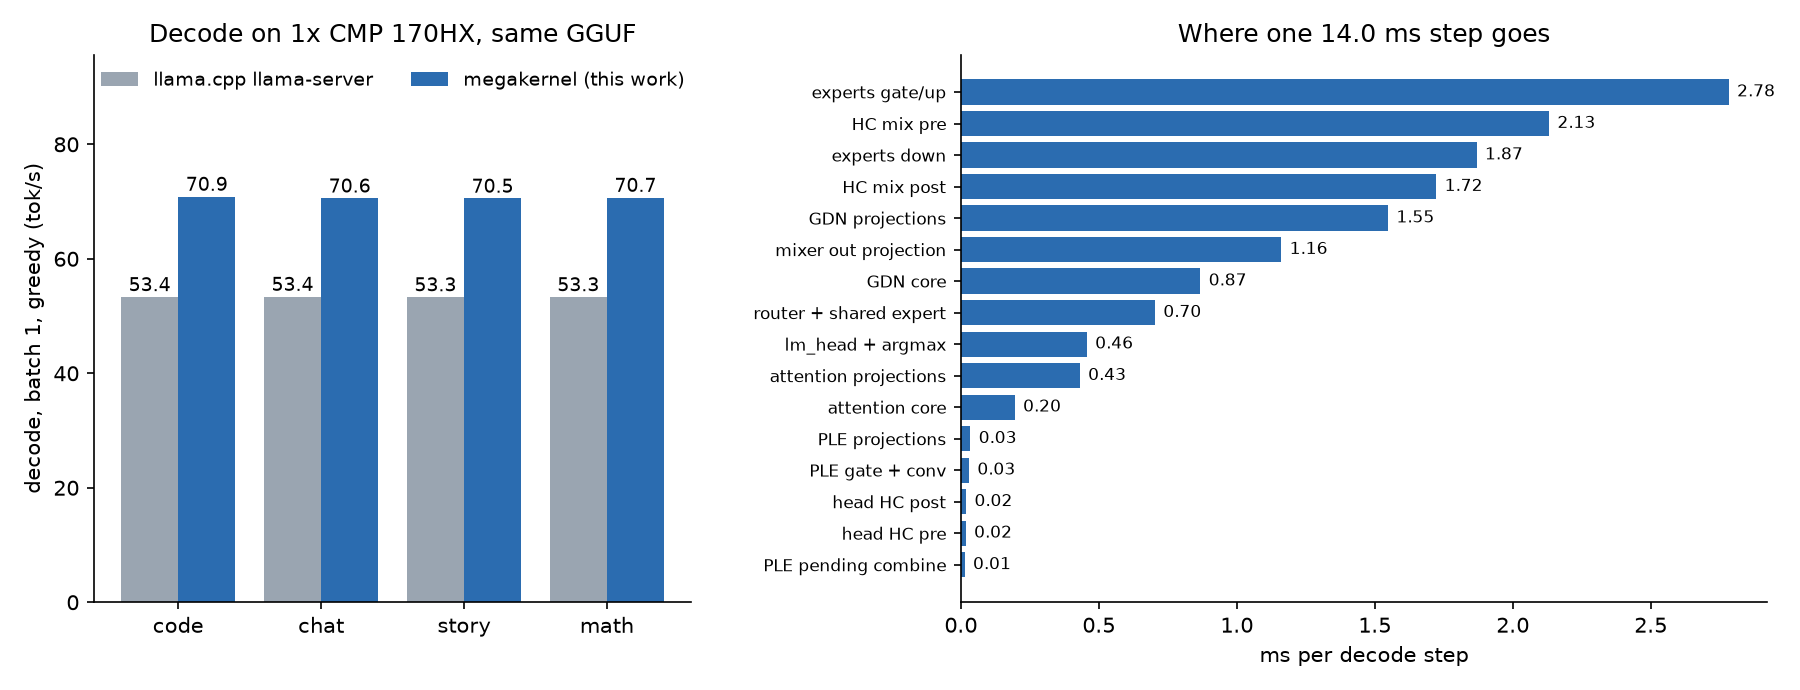

In [4]:
display(Image(filename=os.path.join("..", "assets", "charts", EXPERIMENT + ".png")))

### Decode per prompt (greedy, up to 512 tokens; megakernel reps 0–2, llama-server warm rounds 1–2)

In [5]:
rows = []
for p in ["code", "chat", "story", "math"]:
    rows.append([p, m["gen_tokens"][p], " / ".join(f"{v:.2f}" for v in m["decode_tok_s_all_runs"][p]), m["decode_tok_s_median_by_prompt"][p],
                 " / ".join(f"{v:.2f}" for v in l["server_decode_tok_s_by_prompt_rounds"][p]), l["server_decode_tok_s_median_warm"][p],
                 f'{m["decode_tok_s_median_by_prompt"][p] / l["server_decode_tok_s_median_warm"][p]:.2f}x'])
render_table(["Prompt", "Tokens", "Megakernel runs (tok/s)", "Median", "llama.cpp r0/r1/r2 (tok/s)", "Warm median", "Ratio"], rows)
print("llama.cpp round 0 is the cold round (page cache, CUDA graphs); it is excluded from its median.")

| Prompt | Tokens | Megakernel runs (tok/s) | Median | llama.cpp r0/r1/r2 (tok/s) | Warm median | Ratio |
|---|---|---|---|---|---|---|
| code | 512 | 68.78 / 71.08 / 70.88 | 70.88 | 34.05 / 53.40 / 53.31 | 53.35 | 1.33x |
| chat | 512 | 68.52 / 71.07 / 70.58 | 70.58 | 33.20 / 53.46 / 53.35 | 53.4 | 1.32x |
| story | 512 | 68.18 / 71.03 / 70.55 | 70.55 | 32.82 / 53.30 / 53.37 | 53.33 | 1.32x |
| math | 272 | 69.51 / 71.22 / 70.70 | 70.7 | 41.62 / 53.24 / 53.45 | 53.34 | 1.33x |

llama.cpp round 0 is the cold round (page cache, CUDA graphs); it is excluded from its median.


### Correctness: teacher-forced on llama.cpp's greedy output

The megakernel reads llama.cpp's 512-token greedy continuation one token at a time and predicts the next token. A miss is a position where its argmax differs. `gap` is llama.cpp's own top-1 minus top-2 log-prob at that position: a small gap means llama.cpp itself was nearly tied there.

In [6]:
c = S["correctness"]
mg = json.load(open(os.path.join(RESULTS_DIR, "raw", "margins.json")))
render_table(["Prompt", "Agree / positions", "Miss positions (gap)", "Median gap, all positions"],
             [[p, f'{v["agree"]} / {v["total"]}', ", ".join(f"{k} ({g:.3f})" for k, g in mg[p]["miss_logprob_gap"].items()) or "—",
               c["median_gap_all_positions"][p]] for p, v in c["teacher_forced"].items()])

| Prompt | Agree / positions | Miss positions (gap) | Median gap, all positions |
|---|---|---|---|
| code | 510 / 512 | 199 (0.064), 339 (0.133) | 9.82 |
| chat | 508 / 512 | 343 (0.143), 431 (0.000), 473 (0.052), 486 (0.041) | 3.081 |
| story | 499 / 512 | 31 (0.141), 63 (0.365), 108 (0.495), 154 (0.012), 212 (0.115), 219 (0.007), 227 (0.097), 297 (0.073), 331 (0.008), 360 (0.001), 404 (0.047) | 2.247 |
| math | 353 / 354 | 135 (0.095) | 12.616 |

### Where the time goes (one decode step, 486 grid barriers at 1.435 µs each)

Block 0 timestamps every grid barrier. A phase's time includes its barrier wait.

In [7]:
render_table(["Phase", "Per step", "µs each", "ms per step"],
             [[p["phase"], p["count"], p["us_each"], round(p["us_per_step"] / 1000, 3)] for p in m["phases"]])
print(f'profiled step {m["step_ms_profiled"]} ms; barriers alone {m["barriers_per_step"] * m["grid_barrier_us"] / 1000:.2f} ms')
print(open(os.path.join(RESULTS_DIR, "raw", "phases.txt")).read())

| Phase | Per step | µs each | ms per step |
|---|---|---|---|
| PLE projections | 1 | 34.5 | 0.035 |
| PLE pending combine | 1 | 13.85 | 0.014 |
| PLE gate + conv | 1 | 29.7 | 0.03 |
| HC mix pre (attn) | 48 | 22.85 | 1.097 |
| HC mix post (attn) | 48 | 18.18 | 0.872 |
| GDN projections | 36 | 43.01 | 1.548 |
| GDN core | 36 | 24.11 | 0.868 |
| attention projections | 12 | 35.92 | 0.431 |
| attention core | 12 | 16.28 | 0.195 |
| mixer out projection | 48 | 24.2 | 1.161 |
| HC mix pre (ffn) | 48 | 21.56 | 1.035 |
| HC mix post (ffn) | 48 | 17.72 | 0.851 |
| router + shared expert | 48 | 14.66 | 0.704 |
| experts gate/up | 48 | 57.97 | 2.783 |
| experts down | 48 | 38.94 | 1.869 |
| head HC pre | 1 | 17.83 | 0.018 |
| head HC post | 1 | 19.2 | 0.019 |
| lm_head + argmax | 1 | 456.65 | 0.457 |

profiled step 13.986 ms; barriers alone 0.70 ms
mix_pre dbg  2:   10.61 us
mix_pre dbg  6:    8.22 us
mix_pre dbg 10:    7.46 us
mix_pre dbg 18:    9.74 us
mix_pre dbg 30:    4.56 us
phase mix_pre    full   17.06 us | no-gemv   10.60 us | full again   16.92 us
phase mix_post   full   17.68 us | no-gemv   17.66 us | full again   17.73 us
phase lin_proj   full   42.51 us | no-gemv   42.55 us | full again   42.60 us
phase lin_core   full   27.35 us | no-gemv   27.38 us | full again   27.37 us
phase mix_out    full   19.09 us | no-gemv   18.98 us | full again   19.02 us
phase router     full   11.33 us | no-gemv   11.30 us | full again   11.30 us
phase experts_gu full   54.60 us | no-gemv    9.11 us | full again   43.78 us
phase down       full   27.62 us | no-gemv    6.57 us | full again   27.45 us
phase head       full  455.00 us | no-gemv  455.05 us | full again  454.87 us
phase empty      full    1.47 us | no-gemv    1.39 us | full again    1.38 us



### Thermals and power (1 Hz `nvidia-smi`)

In [8]:
render_table(["Run", "Samples", "Busy mean W", "Peak W", "Peak core °C", "Peak mem °C", "SM MHz busy", "HBM MHz"],
             [[n, g["samples"], g["busy_mean_power_w"], g["peak_power_w"], g["peak_core_c"], g["peak_mem_c"], g["sm_clock_mhz_busy_median"], g["mem_clock_mhz"]]
              for n, g in [("megakernel bench", m["gpu"]), ("llama-server bench", l["gpu"])]])

| Run | Samples | Busy mean W | Peak W | Peak core °C | Peak mem °C | SM MHz busy | HBM MHz |
|---|---|---|---|---|---|---|---|
| megakernel bench | 184 | 202.6 | 218.59 | 77.0 | 79.0 | 1470.0 | 1728.0 |
| llama-server bench | 131 | 181.4 | 223.39 | 82.0 | 80.0 | 1470.0 | 1728.0 |

## 3. Reproduce

**Hardware.** 1x CMP 170HX with the 64 GB / 74 SM unlock ([docs/INSTALLATION.md](../docs/INSTALLATION.md)), forced airflow, ≥ 32 GB host RAM, and **~30 GB free on a local disk** for the PLE table (a network mount makes the per-token row gather 25x slower, see the appendix). Power limit: card default, no tuning.

**1. Container and build deps**

```bash
docker run --gpus all -it --rm -v $MODELS:/models -v $LOCAL:/local docker.io/nvidia/cuda@sha256:020bc241a628776338f4d4053fed4c38f6f7f3d7eb5919fecb8de313bb8ba47c bash
apt-get update && apt-get install -y git cmake python3-venv
python3 -m venv /root/venv && /root/venv/bin/pip install "huggingface_hub" gguf numpy
```

**2. Weights** (83.8 GiB) and the PLE table copy (26.8 GiB, ~3 min)

```bash
/root/venv/bin/hf download unsloth/Qwen3.8-Flash-Next-GGUF --revision 766911a6b7369840a91dbcd95f9f997acaab6cd6 --include "UD-Q3_K_XL/*" --local-dir /models
sha256sum /models/UD-Q3_K_XL/*.gguf   # compare with the HF file page
/root/venv/bin/python -I src/extract_ple.py /models/UD-Q3_K_XL/Qwen3.8-Flash-Next-UD-Q3_K_XL-00002-of-00003.gguf /local/ple.bin
```

**3. Build** llama.cpp (tokenizer + ggml dequant; CPU-only is enough) and the engine

```bash
git clone https://github.com/ggml-org/llama.cpp && git -C llama.cpp checkout aa94f2086147cd4bfbcff818ce998dffce5fcb39
cmake -S llama.cpp -B llama.cpp/build-cpu -DGGML_CUDA=OFF -DLLAMA_CURL=OFF -DCMAKE_BUILD_TYPE=Release
cmake --build llama.cpp/build-cpu -j8 --target llama
cd src && make LLAMA=../llama.cpp BUILD=../llama.cpp/build-cpu ARCH=sm_80
```

**4. Run.** The first run repacks the GGUF and writes a 57 GiB weight cache (~4 min); later runs load it in ~95 s.

```bash
MODELS=/models LOCAL=/local ./run.sh -p "Write a quicksort function in C with comments." -n 512
MODELS=/models LOCAL=/local ./run.sh --bench prompts.tsv --reps 3 -n 512 > fnx_bench.jsonl   # this notebook's benchmark
MK_PROFILE=1 MODELS=/models LOCAL=/local ./run.sh -n 128                                     # per-phase timing
```

**5. llama.cpp reference** (CUDA build, same commit)

```bash
cmake -S llama.cpp -B llama.cpp/build-sm80 -DGGML_CUDA=ON -DCMAKE_CUDA_ARCHITECTURES=80 -DLLAMA_CURL=OFF && cmake --build llama.cpp/build-sm80 -j8 --target llama-server llama-bench
llama.cpp/build-sm80/bin/llama-server -m /models/UD-Q3_K_XL/Qwen3.8-Flash-Next-UD-Q3_K_XL-00001-of-00003.gguf \
  -ngl 99 -ot "per_layer_token_embd=CPU" -fa on -c 4096 -np 1 --port 8090 --host 127.0.0.1
python3 src/ref_llamacpp.py ref 512 && ./run.sh --score ref/story.ids --score-prompt 29
llama.cpp/build-sm80/bin/llama-bench -m <shard 1> -ngl 99 -ot "per_layer_token_embd=CPU" -fa 1 -p 512 -n 128 -r 3
```

Rebuild the summary and chart: `python3 src/summarize.py --chart`.

## 4. Appendix

<details><summary>How the engine works, what it skips, how it got from 29 to 71 tok/s, and the caveats</summary>

**Model.** `qwen4exp`: 48 layers (36 Gated DeltaNet + 12 gated attention with a QSA indexer), 4-stream hyper-connections (low rank 320) in place of layer norms, 512 experts top-10 (640 wide) + one shared expert, a 3-gram hashed PLE embedding (16 heads x 160, 320 M rows) injected at layer 1 with a dilated causal conv, vocab 248,320, and one MTP block (unused here).

**One step = one launch.** 74 blocks x 512 threads, cooperative launch, 486 software grid barriers (release-add / acquire-poll, the open-jet scheme, 1.435 µs each). Per layer: HC mix (two phases) → token mixer (projections, core, out) → HC mix → router + shared expert → expert gate/up → expert down. The host reads back one token id.

**Weights.** Dense matrices run as Q8_0 (Q5_K/Q6_K tensors re-quantised to Q8_0 at load); experts stay IQ3_XXS (gate/up), IQ4_NL (down; one IQ4_XS layer converted to IQ4_NL with fp16 block scales) or Q8_0; norms and routers stay f32. Activations are quantised to int8 per 32 and every dot uses `dp4a`.

**Scope limits (v1).** Batch 1, greedy only, no speculative decoding (the MTP head is not loaded), context ≤ 2,048 tokens. Up to 2,048 cached cells the QSA indexer (budget 2,048) keeps every cell, so dense attention is exact; beyond that the indexer would be needed. Prompts are fed token by token through the decode kernel (no batched prefill), so prompt throughput equals decode throughput. No HTTP server.

**Steps (measured on the same card, `code` prompt, during development; these intermediate builds are not in the receipts):**

| Change | Decode (tok/s) |
|---|---|
| first correct version, PLE table read from the network model mount | 29.4 |
| PLE table copied to local disk (16 random 90-byte reads: 18.1 ms → 0.75 ms per token) | 51.1 |
| open-jet's release/acquire barrier in place of a generation-flag barrier (1.43 µs) | 52.6 |
| batched loads in every GEMV (all weight loads issued before the math), 2 rows per warp | 55.9 |
| HC mix-pre: one hc stream per block (no grid-wide 40 KB staging), smem-broadcast inject weights | 69.5 |
| shared-memory dequant tables, type-specialised expert loops | ~70.6 (final) |

Tried and reverted: 2 rows per warp in expert-down (register spills, 63.3 tok/s).

**Where it stands (inferred, computed from the tensor shapes).** One step reads ~5.8 GB of weights: 4.05 GB of Q8_0 dense matrices (GDN / attention projections and the hyper-connection mixers), 1.04 GB of routed experts and 0.68 GB of lm_head. At 70.64 tok/s that is ~410 GB/s, about 27% of the ~1.5 TB/s HBM peak (community-reported). The rest is latency: 486 barriers cost ~0.7 ms, and most phases are 10–60 µs with little work per block. The next levers are fewer phases (fuse HC mix-post into the next projection, router into gate/up), a batched prefill kernel, and MTP speculation as open-jet does for the 27B.

**Why not vLLM (inferred, not tested here).** 177 B parameters do not fit 64 GB at 4+ bits; NVIDIA's NVFP4 checkpoint is ~124 GiB and NVFP4 needs SM90+. The only single-card path is a ≤3.5-bit GGUF. On Qwen3.8-27B, where vLLM fits, the sibling notebook ([PR #85](https://github.com/PixelML/club-170hx/pull/85)) measured vLLM W4A16 + DFlash2 at 1.6–2.5x the open-jet megakernel.

**llama.cpp cold round.** Round 0 of llama-server ran at 32.8–41.6 tok/s while the mmapped GGUF and CUDA graphs warmed up; rounds 1–2 settle at 53.2–53.5. `llama-bench` tg128 reports 34.79 tok/s (its PLE rows are read from the network mount, as in round 0).

**Thermal caution.** No power cap was set (VBIOS default 250 W). The megakernel bench peaked at 77 °C core / 79 °C memory. The llama-server bench peaked at **82 °C core**, above this repository's 80 °C stop rule; it was not stopped. Cap the card (for example `nvidia-smi -pl 180`) before long runs.

**Correctness method.** A first 256-token round (`raw/ref/`) scored 99.6 / 100 / 97.3 / 99.6 % on the same prompts and was superseded by the 512-token round. The `story` prompt has the lowest median gap (2.25 nats) and the most near-ties, so it shows the most misses.

</details>

### Editable final request (the engine has no HTTP API; this is the CLI call to edit and run)

In [9]:
cmd = 'MODELS=/models LOCAL=/local ./run.sh -p "Explain how a hash map works, in simple terms." -n 256'
print(cmd)

MODELS=/models LOCAL=/local ./run.sh -p "Explain how a hash map works, in simple terms." -n 256
